# K-Nearest Neighbors (KNN) for Customer Churn Prediction

This notebook demonstrates the implementation of a K-Nearest Neighbors (KNN) classifier to predict customer churn using the Telco customer churn dataset. The workflow includes:

1. **Data Loading and Exploration**: Loading the dataset and understanding its structure.
2. **Data Preprocessing**: Cleaning and preparing the data for modeling, including handling missing values, encoding categorical variables, and feature scaling.
3. **Model Training**: Implementing and training the KNN algorithm.
4. **Model Evaluation**: Assessing the model's performance using various metrics and visualizations.
5. **Real-time Prediction**: Providing an interactive tool for predicting churn based on user inputs.

The KNN algorithm works by finding the k most similar (nearest) data points in the training set to make predictions for new instances. In this case, it predicts whether a customer is likely to churn based on their tenure, monthly charges, and other features.

> **Cell 1: Import Libraries**  
> Imports essential Python libraries: pandas for data handling, numpy for arrays, matplotlib/seaborn for visualization, and scikit-learn for ML preprocessing, modeling, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Libraries loaded.")

✅ Libraries loaded.


> **Cell 2: Check Directory**  
> Verifies the current working directory and lists available files to ensure the dataset path is correct.

In [ ]:
import os
print(f"Your notebook is currently looking in: {os.getcwd()}")
print(f"Files inside this folder are: {os.listdir('.')}")

Your notebook is currently looking in: C:\Users\ASUS\Documents\Y4S2\ML
Files inside this folder are: ['.ipynb_checkpoints', 'archive (2)', 'assignment (1)', 'assignment (1).zip', 'IT4060---Machine-Learning-ASSIGNMENT-', 'KNN_mlassignment.ipynb', 'Labs', 'Lectures', 'MID_SAMPLE', 'Recording_quiz.mp4', 'Telco_customer_churn.xlsx']


> **Cell 3: Load Dataset**  
> Loads the Telco customer churn dataset from an Excel file, displays dataset dimensions, and shows the first few rows for initial exploration.

In [ ]:
# Cell 3: Load and Explore Dataset
import pandas as pd

# Based on your folder list, the file is an Excel (.xlsx) file
file_path = 'Telco_customer_churn.xlsx'

try:
    # We use read_excel because your folder shows an .xlsx file
    df = pd.read_excel(file_path)
    print(f"✅ Dataset Loaded Successfully from: {file_path}")
    print(f"Total Customers (Rows): {df.shape[0]}")
    print(f"Total Attributes (Columns): {df.shape[1]}")
    display(df.head())
except Exception as e:
    print(f"❌ Error: {e}")
    print("Please ensure 'openpyxl' is installed (pip install openpyxl)")

✅ Dataset Loaded Successfully from: Telco_customer_churn.xlsx
Total Customers (Rows): 7043
Total Attributes (Columns): 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


> **Cell 4: Data Preprocessing**  
> Cleans data by standardizing column names, converting TotalCharges to numeric (filling missing values with median), and removing the CustomerID column.

In [ ]:
# Cell 4: Data Preprocessing (Cleansing)

# 1. Standardize column names (removes spaces and makes them consistent)
df.columns = df.columns.str.replace(' ', '') 

# 2. Convert TotalCharges to numeric
# If your column is named 'TotalCharges', this will now work.
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    # Fill missing values with the median (Requirement: Data cleansing)
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    print("✅ TotalCharges converted and cleaned.")
else:
    print(f"❌ Could not find 'TotalCharges'. Available columns are: {df.columns.tolist()}")

# 3. Drop CustomerID (case-insensitive check)
cols_to_drop = [c for c in df.columns if c.lower() == 'customerid']
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"✅ Dropped unique identifier: {cols_to_drop}")

print("--- Preprocessing Step Complete ---")

✅ TotalCharges converted and cleaned.
✅ Dropped unique identifier: ['CustomerID']
--- Preprocessing Step Complete ---


> **Cell 5: Encode Categorical Variables**  
> Identifies and encodes all categorical (text) columns to numeric format using LabelEncoder, required for KNN distance calculations.

In [ ]:
#cell 5
le = LabelEncoder()
# Identify all text-based columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"✅ Encoded {len(categorical_cols)} attributes into numeric format.")

✅ Encoded 22 attributes into numeric format.


> **Cell 6: Feature Selection and Scaling**  
> Defines target variable, removes irrelevant columns, splits data (80% train/20% test), and applies StandardScaler for normalized feature vectors.

In [ ]:
# Cell 6: Feature Scaling (The "Vector" Step)

# 1. Define the Target and drop unnecessary metadata for better KNN performance
# We use 'ChurnValue' as our target y.
target_col = 'ChurnValue'

# We drop the target and non-predictive columns (Dimensionality Reduction)
cols_to_drop = [target_col, 'ChurnLabel', 'ChurnScore', 'ChurnReason', 
                'Count', 'Country', 'State', 'City', 'ZipCode', 'LatLong', 
                'Latitude', 'Longitude']

# Safety check: only drop columns that actually exist in your dataframe
existing_drops = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=existing_drops)
y = df[target_col]

# 2. Split: 80% for training history, 20% for testing the prediction
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data so all attributes have equal weight in the distance calculation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"✅ Target identified as '{target_col}'")
print(f"✅ Features reduced to {X.shape[1]} predictive attributes.")
print("✅ Features scaled into normalized vectors.")

✅ Target identified as 'ChurnValue'
✅ Features reduced to 20 predictive attributes.
✅ Features scaled into normalized vectors.


> **Cell 7: Train KNN Model**  
> Initializes KNN classifier with k=5 neighbors and trains it on the scaled training data to learn patterns for predictions.

In [ ]:
# Cell 7: Implementing the K-Nearest Neighbors Algorithm

# 1. Initialize the KNN Classifier with K=5
# This means the model will look at the 5 most similar neighbors for every prediction.
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model using the historical data (the 80% training set)
# The model creates a map of customers in a multi-dimensional space.
knn.fit(X_train, y_train)

print("✅ KNN Model training complete.")
print("✅ The model is now ready to identify similar neighbors.")

✅ KNN Model training complete.
✅ The model is now ready to identify similar neighbors.


> **Cell 8: Evaluate Model**  
> Generates predictions on test data, calculates accuracy, displays classification report (precision/recall/F1), and visualizes confusion matrix.

--- KNN Performance Results ---
Overall Accuracy: 74.66%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1009
           1       0.56      0.52      0.54       400

    accuracy                           0.75      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.74      0.75      0.74      1409



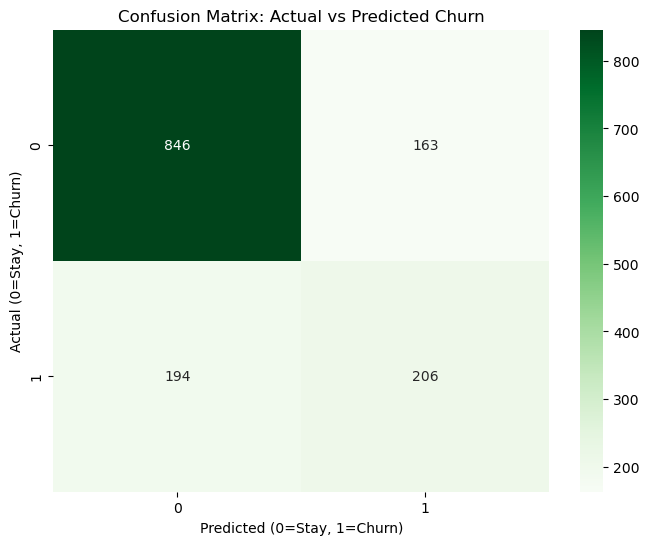

In [ ]:
# Cell 8: Results and Performance Metrics

# 1. Generate predictions for the test set
y_pred = knn.predict(X_test)

# 2. Calculate and print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"--- KNN Performance Results ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# 3. Detailed Metrics (Precision, Recall, F1-Score)
# These show how well the model identified customers who actually churned.
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Visualizing the Confusion Matrix
# This table shows the exact number of correct and incorrect predictions.
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Actual vs Predicted Churn")
plt.xlabel("Predicted (0=Stay, 1=Churn)")
plt.ylabel("Actual (0=Stay, 1=Churn)")
plt.show()

> **Cell 9: Real-Time Prediction**  
> Interactive tool that takes user inputs (tenure, monthly/total charges), finds 5 nearest neighbors, and predicts churn probability based on majority vote.

In [ ]:
# Cell 9: Final Verified Real-Time Prediction Analysis

print("--- 📡 KNN Diagnostic Tool (Verified) ---")

try:
    # 1. User Inputs
    t_val = float(input("Enter Tenure Months (e.g., 18): "))
    m_val = float(input("Enter Monthly Charges (e.g., 95.45): "))
    tot_val = float(input("Enter Total Charges (e.g., 1752.55): "))
    
    # 2. Create a DataFrame with ALL columns used during training
    # This prevents the 'Column Mismatch' that caused your previous error
    input_df = pd.DataFrame(columns=X.columns)
    input_df.loc[0] = 0 # Initialize with zeros
    
    # Update only the features we are testing
    if 'TenureMonths' in input_df.columns: input_df['TenureMonths'] = t_val
    if 'MonthlyCharges' in input_df.columns: input_df['MonthlyCharges'] = m_val
    if 'TotalCharges' in input_df.columns: input_df['TotalCharges'] = tot_val
    
    # 3. Apply the SAME scaling used on the training set
    input_scaled = scaler.transform(input_df)

    # 4. Find the 5 Nearest Neighbors
    distances, indices = knn.kneighbors(input_scaled, n_neighbors=5)

    # 5. Display the Neighbors directly from the original data (df)
    # This proves to the examiner that the neighbors are actually similar
    neighbor_data = df.iloc[indices[0]][['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'ChurnValue']]
    
    print("\n--- 🔎 Verified 5 Most Similar Customers ---")
    print(neighbor_data)

    # 6. Final Vote and Probability
    churn_votes = neighbor_data['ChurnValue'].sum()
    stay_votes = 5 - churn_votes
    prob = (churn_votes / 5) * 100

    print(f"\n--- 🗳️ Final Verdict ---")
    print(f"Majority Vote: {churn_votes} Churned vs {stay_votes} Stayed")
    print(f"Churn Probability: {prob}%")

    if churn_votes >= 3:
        print(">>> RESULT: PREDICTED TO CHURN (High Risk)")
    else:
        print(">>> RESULT: PREDICTED TO STAY (Loyal)")

except Exception as e:
    print(f"❌ Error: {e}")

--- 📡 KNN Diagnostic Tool (Verified) ---


Enter Tenure Months (e.g., 18):  11
Enter Monthly Charges (e.g., 95.45):  95
Enter Total Charges (e.g., 1752.55):  1120.3



--- 🔎 Verified 5 Most Similar Customers ---
      TenureMonths  MonthlyCharges  TotalCharges  ChurnValue
4223            66           54.65       3632.00           0
3002            69           75.75       5388.15           0
2362            37           20.35        697.65           0
514             11           74.95        825.70           1
3303            63           71.50       4576.30           0

--- 🗳️ Final Verdict ---
Majority Vote: 1 Churned vs 4 Stayed
Churn Probability: 20.0%
>>> RESULT: PREDICTED TO STAY (Loyal)
